In [1]:
# Required libraries for 2026 quantitative finance
!pip install yfinance PyPortfolioOpt pandas matplotlib vectorbt plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.7 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
import matplotlib.pyplot as plt

In [3]:
# Investor Input (This can be modified by the user)
INVESTED_CAPITAL = 50000
RISK_LEVEL = "Medium"  # Options: "Low", "Medium", "High"

# Asset Selection (The user defines their universe)
TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA", "BTC-USD", "GC=F", "SPY"]

### Data Ingestion & Returns Calculation

In [4]:
# Fetch 5 years of historical data
data = yf.download(TICKERS, period="5y")['Close']

# Calculate Expected Returns (Mean Historical) and Risk (Ledoit-Wolf Shrinkage)
# Ledoit-Wolf is more robust than a simple sample covariance matrix.
mu = expected_returns.mean_historical_return(data)
S = risk_models.CovarianceShrinkage(data).ledoit_wolf()

/tmp/ipython-input-977322939.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKERS, period="5y")['Close']
[*********************100%***********************]  7 of 7 completed
/usr/local/lib/python3.12/dist-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(


### Optimization Logic based on Risk Profile

In [5]:
ef = EfficientFrontier(mu, S)

if RISK_LEVEL == "Low":
    # Minimizes the volatility regardless of returns
    weights = ef.min_volatility()
    title = "Minimum Volatility Portfolio"
elif RISK_LEVEL == "High":
    # Targets the highest possible return for the risk
    weights = ef.max_sharpe()
    title = "Maximum Sharpe Ratio Portfolio"
else:
    # Medium: Target a specific return (e.g., 15% annually)
    weights = ef.efficient_return(target_return=0.15)
    title = "Balanced Efficient Return Portfolio"

cleaned_weights = ef.clean_weights()
ef.portfolio_performance(verbose=True)

Expected annual return: 19.3%
Annual volatility: 9.6%
Sharpe Ratio: 2.01


(np.float64(0.19255471304156097),
 np.float64(0.0956436916561546),
 np.float64(2.013250531292831))

### Asset Allocation Proposal

In [6]:
# Convert percentage weights into actual share counts
latest_prices = get_latest_prices(data)
da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=INVESTED_CAPITAL)
allocation, leftover = da.greedy_portfolio()

print(f"\n--- Recommended Investment for ${INVESTED_CAPITAL} ---")
for ticker, count in allocation.items():
    print(f"{ticker}: Buy {count} shares")
print(f"Remaining Cash: ${leftover:.2f}")


--- Recommended Investment for $50000 ---
GC=F: Buy 5 shares
SPY: Buy 35 shares
Remaining Cash: $282.67


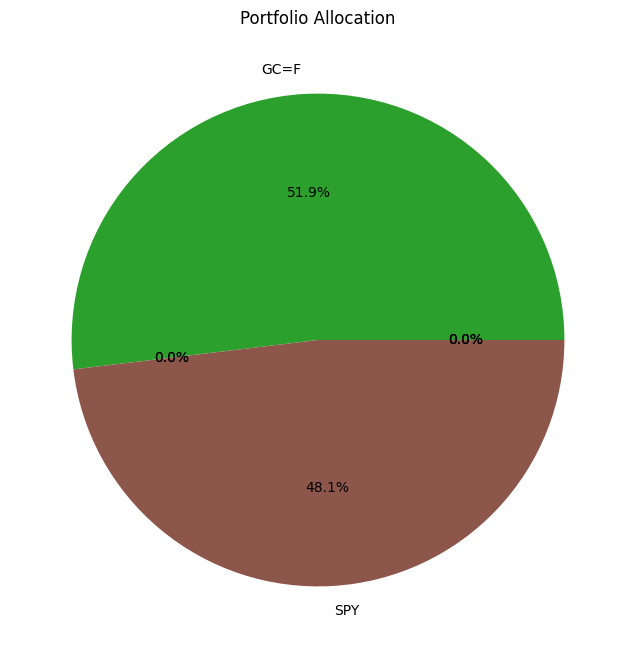

In [7]:
pd.Series(cleaned_weights).plot.pie(figsize=(8, 8), autopct='%1.1f%%', title="Portfolio Allocation")
plt.ylabel("")
plt.show()

In [ ]:
# Import the core backtesting library
import vectorbt as vbt

### Running the Backtest with Optimized Weights

In [12]:
# 1. Prepare data for vectorbt
# 'data' is the OHLCV dataframe from your yfinance fetch
price = data.ffill().bfill() # closing prices, handle NaNs

# Create a DataFrame for target percentages that matches the shape of 'price'
# The cleaned_weights is a dictionary of {ticker: weight}.
# Convert it to a Series, reindex to match price.columns, and then repeat for each date.
weights_series = pd.Series(cleaned_weights).reindex(price.columns, fill_value=0)
target_percent_df = pd.DataFrame([weights_series] * len(price.index), index=price.index)

# 2. Simulate a portfolio based on the optimized weights
# We use 'from_orders' and 'size_type=targetpercent' to apply our specific % allocations
pf = vbt.Portfolio.from_orders(
    close=price,
    size=target_percent_df, # Use the DataFrame of target percentages
    size_type='targetpercent',
    group_by=True,                   # Treats the assets as a single portfolio
    cash_sharing=True,               # Reinvests cash across the assets
    init_cash=INVESTED_CAPITAL
)

In [13]:
# A. The Summary Dashboard (Everything in one view)
pf.plot().show()

# B. Breakdown by Subplots
# Shows Cumulative Returns, Daily Returns, and "Underwater" (Drawdown) plots
pf.plot(subplots=['cum_returns', 'drawdowns', 'underwater']).show()

# C. Statistical Table
print(pf.stats())

/usr/local/lib/python3.12/dist-packages/vectorbt/generic/plots_builder.py:339: UserWarning: Subplot 'orders' does not support grouped data
  warnings.warn(warning_message)
/usr/local/lib/python3.12/dist-packages/vectorbt/generic/plots_builder.py:339: UserWarning: Subplot 'trade_pnl' does not support grouped data
  warnings.warn(warning_message)


Start                         2021-02-11 00:00:00
End                           2026-02-11 00:00:00
Period                         1827 days 00:00:00
Start Value                               50000.0
End Value                           119600.103092
Total Return [%]                       139.200206
Benchmark Return [%]                   243.619401
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        17.791444
Max Drawdown Duration           441 days 00:00:00
Total Trades                                 1134
Total Closed Trades                          1132
Total Open Trades                               2
Open Trade PnL                       38702.375613
Win Rate [%]                            83.303887
Best Trade [%]                         101.580027
Worst Trade [%]                        -11.341168
Avg Winning Trade [%]                   20.439809
Avg Losing Trade [%]                    -3.659397


### Deep Analysis

The key advantage of adding this to your notebook is Trade Logic Validation. While MPT assumes you just "buy and hold" those weights, vectorbt can simulate:

* **Slippage & Fees**: You can add fees=0.001 to see how broker commissions eat your profits.

* **Stop-Losses**: You can add sl_stop=0.05 to see if a 5% protection would have saved the portfolio during a crash.

* **Rebalancing**: You can check how the portfolio drifts over time and simulate re-aligning the weights every month.

By showing the **Underwater Plot** (which displays how long the portfolio spent in a "loss" state), the investor can truly understand their **Risk Willingness**.

**Pro Tip**: If an investor says they have "High Risk Tolerance," but the vectorbt chart shows a 30% drawdown that lasted 8 months, they might reconsider and choose the "Medium Risk" profile instead.